# Import Libraries:

In [1]:
import math
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline
import pandas as pd

In [2]:
def f(x: float) -> float:
    return 3*x**2- 4*x + 5

In [3]:
f(3.0)


20.0

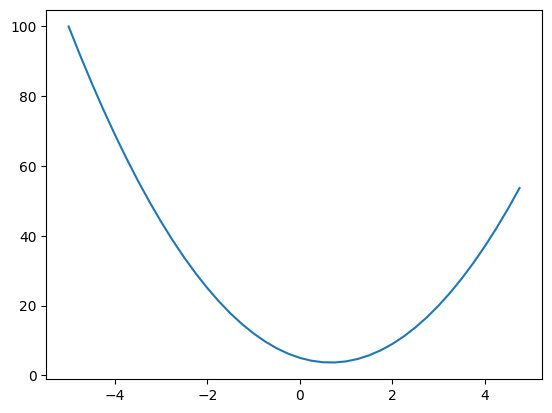

In [4]:
xs = np.arange(-5,5,0.25)
ys = f(xs)
plt.plot(xs,ys)

[99.6603 91.3628 83.4403 75.8928 68.7203 61.9228 55.5003 49.4528 43.7803
 38.4828 33.5603 29.0128 24.8403 21.0428 17.6203 14.5728 11.9003  9.6028
  7.6803  6.1328  4.9603  4.1628  3.7403  3.6928  4.0203  4.7228  5.8003
  7.2528  9.0803 11.2828 13.8603 16.8128 20.1403 23.8428 27.9203 32.3728
 37.2003 42.4028 47.9803 53.9328]


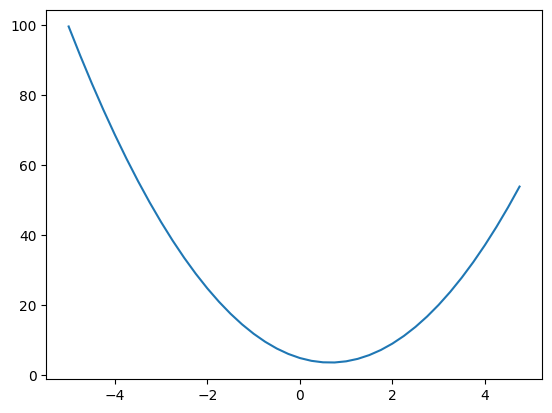

In [5]:
xs = np.arange(-5,5,0.25)
h = 0.01
ys = f(xs + h)
print(ys)
plt.plot(xs,ys)

In [6]:
h = 0.000001
x = 2/3
y = (f(x+h) - f(x))/h
print(y)

2.999378523327323e-06


In [7]:
# Let's get more complex:

h = 0.0001
a = 2.0
b = -3.0
c = 10.0

d1 = a*b+c
b+=h
d2 = a*b +c
print('d1',d1)
print('d2',d2)
print('slope',(d2-d1)/h)

d1 4.0
d2 4.0002
slope 2.0000000000042206


In [8]:
class Value:
    def __init__(self, data, _children=(), _op=''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        
    def __repr__(self):
        return f"Value(data={self.data})"

    
    def __add__(self,other):
        out = Value(self.data + other.data, (self,other),'+')
        return out
    
    def __mul__(self,other):
        out = Value(self.data * other.data, (self,other),'*')
        return out

a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
d

Value(data=4.0)

In [9]:
d._prev

{Value(data=-6.0), Value(data=10.0)}

In [1]:
from graphviz import Digraph

def trace(root):
    # Builds a set of all nodes and edges in graph
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add(child,v)
                build(child)
    build(root)
    return nodes, edges


def draw_dot(root):
    dot  = Digraph(format='svg',graph_attr={'rankdir':'LR'}) # LR = Left to Right
    
    nodes, edges = trace(root)
    for n in nodes:
        uid = str(id(n))
        # for any value in the graph create a rectangular record node for it
        dot.node(name=uid, label="{ data %.4f }" % (n.data, ), shape='record')
        if n._op:
            # if this value is a result of some operation, create an op node for it
            dot.nose(name= uid + n._op, label=n._op)
            # and connect this node to it:
            dot.edge(uid + n._op, uid)
            
            
    for n1, n2 in edges:
        # connect n1 to the op node of n2:
        dot.edge(str(id(n1)), str(id(n2)) +n2._op)
        
    return dot
    